In [3]:
import pandas as pd

df = pd.read_csv(r"C:\Users\rsang\Downloads\anime.csv")

In [4]:
print(df.shape)
print(df.columns)
print(df.head())

(12294, 7)
Index(['anime_id', 'name', 'genre', 'type', 'episodes', 'rating', 'members'], dtype='object')
   anime_id                              name  \
0     32281                    Kimi no Na wa.   
1      5114  Fullmetal Alchemist: Brotherhood   
2     28977                          Gintama°   
3      9253                       Steins;Gate   
4      9969                     Gintama&#039;   

                                               genre   type episodes  rating  \
0               Drama, Romance, School, Supernatural  Movie        1    9.37   
1  Action, Adventure, Drama, Fantasy, Magic, Mili...     TV       64    9.26   
2  Action, Comedy, Historical, Parody, Samurai, S...     TV       51    9.25   
3                                   Sci-Fi, Thriller     TV       24    9.17   
4  Action, Comedy, Historical, Parody, Samurai, S...     TV       51    9.16   

   members  
0   200630  
1   793665  
2   114262  
3   673572  
4   151266  


In [5]:
print(df.isnull().sum())

anime_id      0
name          0
genre        62
type         25
episodes      0
rating      230
members       0
dtype: int64


In [8]:
df = df.dropna(subset =["rating"]).copy()
df["genre"]= df["genre"].fillna("Unknown")
df["type"] = df["type"].fillna("Unknown")
print("Cleaned shape:", df.shape)

Cleaned shape: (12064, 7)


In [9]:
print(df.isnull().sum())

anime_id    0
name        0
genre       0
type        0
episodes    0
rating      0
members     0
dtype: int64


In [13]:
print(df.sort_values("rating", ascending = False).head(5)["name"])
df["type"].value_counts()

10464    Taka no Tsume 8: Yoshida-kun no X-Files
10400                Spoon-hime no Swing Kitchen
9595                            Mogura no Motoro
0                                 Kimi no Na wa.
9078                                Kahei no Umi
Name: name, dtype: object


type
TV         3671
OVA        3285
Movie      2297
Special    1671
ONA         652
Music       488
Name: count, dtype: int64

In [14]:
popular_df = df[df["members"] > 1000]

In [16]:
popular_df.sort_values("rating", ascending = False).head(5)["name"]

0                      Kimi no Na wa.
1    Fullmetal Alchemist: Brotherhood
2                            Gintama°
3                         Steins;Gate
4                       Gintama&#039;
Name: name, dtype: object

In [17]:
df.sort_values("members", ascending = False).head(1)["name"]

40    Death Note
Name: name, dtype: object

In [18]:
df.groupby("type")["rating"].mean()

type
Movie      6.318058
Music      5.588996
ONA        5.643298
OVA        6.375221
Special    6.523501
TV         6.902299
Name: rating, dtype: float64

In [19]:
import matplotlib.pyplot as plt

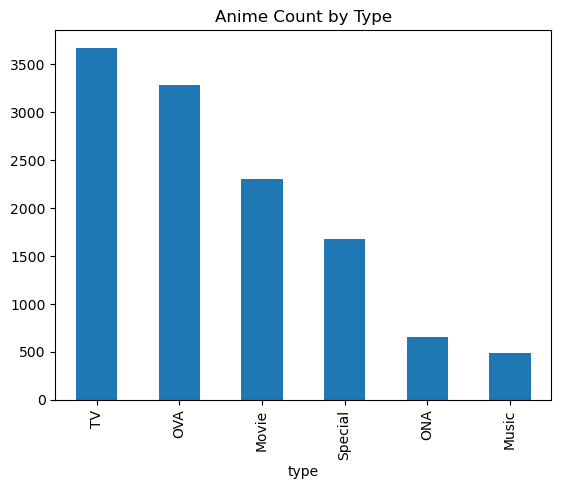

In [22]:
df["type"].value_counts().plot(kind = "bar", title = "Anime Count by Type")
plt.show()

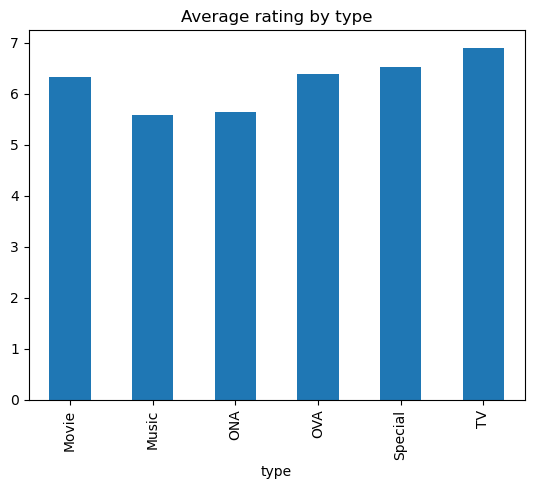

In [23]:
df.groupby("type")["rating"].mean().plot(kind = "bar", title = "Average rating by type")
plt.show()

In [29]:
top10 = df.sort_values("members", ascending = False).head(10)
print(top10)

     anime_id                              name  \
40       1535                        Death Note   
86      16498                Shingeki no Kyojin   
804     11757                  Sword Art Online   
1        5114  Fullmetal Alchemist: Brotherhood   
159      6547                      Angel Beats!   
19       1575   Code Geass: Hangyaku no Lelouch   
841        20                            Naruto   
3        9253                       Steins;Gate   
445     10620                  Mirai Nikki (TV)   
131      4224                         Toradora!   

                                                 genre type episodes  rating  \
40   Mystery, Police, Psychological, Supernatural, ...   TV       37    8.71   
86        Action, Drama, Fantasy, Shounen, Super Power   TV       25    8.54   
804          Action, Adventure, Fantasy, Game, Romance   TV       25    7.83   
1    Action, Adventure, Drama, Fantasy, Magic, Mili...   TV       64    9.26   
159        Action, Comedy, Drama, Scho

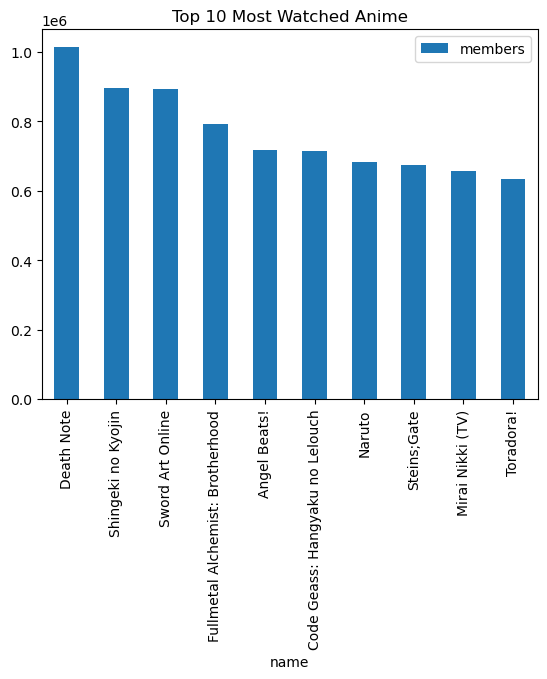

In [30]:
top10.plot(x = "name", y = "members",kind = "bar", title = "Top 10 Most Watched Anime")
plt.show()